# V5 映射：LTspice 与 Python 一致性验证

本 Notebook 使用固定随机种子 42，从训练集与测试集的合并窗口池中随机抽取 3 个窗口，每个窗口随机选择 6 个原始通道。每个通道分离为正、负两个极性分支，因此每种求解器共验证 36 条分支。

V5 映射规则：

- 极性幅值为 0 时，Vin 保持在 0.7562 V；
- 极性幅值非零时，按逐通道 p1/p99 在 1.8639～3.7278 V 之间线性映射；
- 正、负极性分别使用前 16 个和后 16 个映射通道；
- 每个 200 ms 窗口使用 40 个 5 ms 样本，并以 4.999 ms 保持、1 μs 过渡生成 PWL。

每个窗口分别绘制 LTspice 与 Python 结果，只展示 12 个极性分支的极性幅值、Vin、final_out 和 5 ms 二值脉冲编码。最后通过脉冲总数、逐时间箱完全一致率和 final_out 波形误差判断两个求解器是否一致。

In [1]:
# 1. 参数、依赖和项目路径
RANDOM_SEED = 42
WINDOW_COUNT = 3
CHANNELS_PER_WINDOW = 6
SOURCE_CHANNEL_COUNT = 16
SPIKE_BINS = 40
IDLE_VOLTAGE = 0.7562
ACTIVE_BASELINE_VOLTAGE = 1.8639
MAXIMUM_VOLTAGE = 3.7278
TRANSITION_SECONDS = 1e-6
import csv
import importlib.util
import json
import math
import sys
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display
from tqdm.auto import tqdm

# Path 在导入后重新构造，避免依赖 Notebook 的启动目录。
LTSPICE_EXECUTABLE = Path(r"D:\Software\LTspice\LTspice.exe")


def find_project_root():
    """从当前目录向上寻找本验证依赖的项目文件。"""
    start = Path.cwd().resolve()
    for candidate in (start, *start.parents):
        required = (
            candidate / "ninapro_data/processed/exerciseA/slide_window/metadata.json",
            candidate / "neurophic_system_model/System_with_TIA.asc",
            candidate / "neurophic_system_model/system_with_tia.py",
        )
        if all(path.is_file() for path in required):
            return candidate
    raise FileNotFoundError("未找到 SNN_for_Ninapro 项目根目录")


def load_module(module_name, path):
    """从给定路径加载模块，并确保 dataclass 等机制能找到模块对象。"""
    spec = importlib.util.spec_from_file_location(module_name, path)
    if spec is None or spec.loader is None:
        raise ImportError(f"无法加载模块：{path}")
    module = importlib.util.module_from_spec(spec)
    sys.modules[module_name] = module
    spec.loader.exec_module(module)
    return module


PROJECT_ROOT = find_project_root()
SOURCE_ROOT = PROJECT_ROOT / "ninapro_data/processed/exerciseA/slide_window"
MODEL_ROOT = PROJECT_ROOT / "neurophic_system_model"
ASC_PATH = MODEL_ROOT / "System_with_TIA.asc"
PYTHON_MODEL_PATH = MODEL_ROOT / "system_with_tia.py"
LTSPICE_HELPER_PATH = MODEL_ROOT / "16_channels_input_sample/simulate_and_plot.py"
STATISTICS_PATH = MODEL_ROOT / "ninapro_db5_exerciseA_channel_ranges/channel_statistics_overall.csv"
RESULT_ROOT = PROJECT_ROOT / "test_notebooks/verify_mapping_V5_results"
RESULT_ROOT.mkdir(parents=True, exist_ok=True)

for required_path in (
    ASC_PATH,
    PYTHON_MODEL_PATH,
    LTSPICE_HELPER_PATH,
    STATISTICS_PATH,
    SOURCE_ROOT / "train.npz",
    SOURCE_ROOT / "test.npz",
):
    if not required_path.is_file():
        raise FileNotFoundError(f"缺少验证依赖：{required_path}")

print(f"项目根目录：{PROJECT_ROOT}")
print(f"LTspice：{LTSPICE_EXECUTABLE}")
print(f"结果目录：{RESULT_ROOT}")

项目根目录：C:\Users\Fortyfour\Desktop\SNN_for_Ninapro
LTspice：D:\Software\LTspice\LTspice.exe
结果目录：C:\Users\Fortyfour\Desktop\SNN_for_Ninapro\test_notebooks\verify_mapping_V5_results


In [2]:
# 2. 加载窗口、分位点并执行可复现随机抽样
def load_npz(path):
    """一次性复制 NPZ 数组，避免后续访问已关闭的压缩文件。"""
    with np.load(path, allow_pickle=False) as loaded:
        return {name: loaded[name].copy() for name in loaded.files}


SOURCE_METADATA = json.loads(
    (SOURCE_ROOT / "metadata.json").read_text(encoding="utf-8")
)
SOURCE_DATA = {
    split_name: load_npz(SOURCE_ROOT / f"{split_name}.npz")
    for split_name in ("train", "test")
}
SAMPLE_RATE = float(SOURCE_METADATA["sample_rate_hz"])
WINDOW_SAMPLES = int(SOURCE_METADATA["window_samples"])
WINDOW_DURATION = WINDOW_SAMPLES / SAMPLE_RATE

statistics = pd.read_csv(STATISTICS_PATH).sort_values("channel")
if statistics.shape[0] != SOURCE_CHANNEL_COUNT:
    raise ValueError(f"逐通道统计量数量异常：{statistics.shape[0]}")
P1 = statistics["p1"].to_numpy(dtype=np.float64)
P99 = statistics["p99"].to_numpy(dtype=np.float64)
if not np.all(P1 < 0.0) or not np.all(P99 > 0.0):
    raise ValueError("V5 要求所有通道满足 p1 < 0 < p99")

rng = np.random.default_rng(RANDOM_SEED)
train_count = int(SOURCE_DATA["train"]["X"].shape[0])
test_count = int(SOURCE_DATA["test"]["X"].shape[0])
combined_count = train_count + test_count
global_indices = rng.choice(combined_count, size=WINDOW_COUNT, replace=False)

selection_records = []
for window_number, global_index in enumerate(global_indices, start=1):
    if global_index < train_count:
        split_name = "train"
        row_index = int(global_index)
    else:
        split_name = "test"
        row_index = int(global_index - train_count)

    source = SOURCE_DATA[split_name]
    selected_indices = np.sort(
        rng.choice(
            SOURCE_CHANNEL_COUNT,
            size=CHANNELS_PER_WINDOW,
            replace=False,
        )
    )
    label = int(source["y"][row_index])
    action_info = SOURCE_METADATA["label_mapping"][str(label)]
    selection_records.append(
        {
            "window_number": window_number,
            "global_index": int(global_index),
            "split": split_name,
            "row_index": row_index,
            "label": label,
            "raw_label": int(action_info["raw_label"]),
            "action_name_zh": action_info["name_zh"],
            "subject": int(source["subject"][row_index]),
            "repetition": int(source["repetition"][row_index]),
            "start_sample": int(source["start_sample"][row_index]),
            "selected_channel_indices": selected_indices,
            "selected_channels": ";".join(
                str(int(index + 1)) for index in selected_indices
            ),
            "raw_window": source["X"][row_index].astype(
                np.float64,
                copy=True,
            ),
        }
    )

selection_table = pd.DataFrame(
    [
        {
            key: value
            for key, value in record.items()
            if key not in {"selected_channel_indices", "raw_window"}
        }
        for record in selection_records
    ]
)
selection_table.to_csv(
    RESULT_ROOT / "selection_manifest.csv",
    index=False,
    encoding="utf-8-sig",
)
display(selection_table)

,window_number,global_index,split,row_index,label,raw_label,action_name_zh,subject,repetition,start_sample,selected_channels
0,1,17428,train,17428,8,9,拇指内收,10,4,104779,2;3;9;10;13;15
1,2,2376,train,2376,4,5,无名指屈曲,2,3,53975,2;6;7;8;11;16
2,3,20606,test,2767,3,4,中指伸展,4,2,38675,2;4;6;7;10;14


In [3]:
# 3. 定义 V5 映射、PWL 和统一双求解接口
def map_v5(raw_window):
    """将一个 16×40 原始窗口映射为正通道在前、负通道在后的 32×40 Vin。"""
    raw_window = np.asarray(raw_window, dtype=np.float64)
    if raw_window.shape != (SOURCE_CHANNEL_COUNT, WINDOW_SAMPLES):
        raise ValueError(f"窗口形状异常：{raw_window.shape}")

    positive_amplitude = np.maximum(raw_window, 0.0)
    negative_amplitude = np.maximum(-raw_window, 0.0)
    positive_normalized = np.clip(
        positive_amplitude / P99[:, None],
        0.0,
        1.0,
    )
    negative_normalized = np.clip(
        negative_amplitude / (-P1)[:, None],
        0.0,
        1.0,
    )
    voltage_span = MAXIMUM_VOLTAGE - ACTIVE_BASELINE_VOLTAGE
    positive_vin = np.where(
        positive_amplitude == 0.0,
        IDLE_VOLTAGE,
        ACTIVE_BASELINE_VOLTAGE + voltage_span * positive_normalized,
    )
    negative_vin = np.where(
        negative_amplitude == 0.0,
        IDLE_VOLTAGE,
        ACTIVE_BASELINE_VOLTAGE + voltage_span * negative_normalized,
    )
    return np.concatenate((positive_vin, negative_vin), axis=0)


def build_pwl_arrays(vin_sequence):
    """生成 4.999 ms 保持和 1 μs 过渡的 81 个 PWL 控制点。"""
    vin_sequence = np.asarray(vin_sequence, dtype=np.float64)
    if vin_sequence.shape != (WINDOW_SAMPLES,):
        raise ValueError(f"Vin 序列形状异常：{vin_sequence.shape}")

    sample_interval = 1.0 / SAMPLE_RATE
    times = [0.0]
    values = [float(vin_sequence[0])]
    for index, value in enumerate(vin_sequence):
        interval_end = (index + 1) * sample_interval
        times.append(interval_end - TRANSITION_SECONDS)
        values.append(float(value))
        next_value = (
            vin_sequence[index + 1]
            if index + 1 < WINDOW_SAMPLES
            else value
        )
        times.append(interval_end)
        values.append(float(next_value))
    return np.asarray(times), np.asarray(values)


def write_pwl(path, times, values):
    """使用 LTspice 可直接读取的 ASCII 两列格式写入临时 PWL。"""
    lines = [
        f"{time_value:.9f} {voltage_value:.9f}"
        for time_value, voltage_value in zip(times, values)
    ]
    Path(path).write_text("\n".join(lines) + "\n", encoding="ascii")


ltspice_helper = load_module(
    "verify_mapping_v5_ltspice_helper",
    LTSPICE_HELPER_PATH,
)
python_model = load_module(
    "verify_mapping_v5_python_model",
    PYTHON_MODEL_PATH,
)
PARAMETERS = python_model._PARAMETERS


def simulate_branch(vin_sequence, task_root, task_name):
    """用完全相同的 PWL 分别运行 LTspice 和 Python 模型。"""
    pwl_times, pwl_values = build_pwl_arrays(vin_sequence)
    pwl_path = task_root / f"{task_name}.pwl"
    netlist_path = task_root / f"{task_name}.cir"
    write_pwl(pwl_path, pwl_times, pwl_values)
    netlist_path.write_text(
        ltspice_helper.make_netlist(pwl_path, WINDOW_DURATION),
        encoding="utf-8",
    )

    raw_path, _ = ltspice_helper.run_ltspice(
        LTSPICE_EXECUTABLE,
        netlist_path,
        timeout=120,
    )
    lt_raw = ltspice_helper.read_ltspice_raw(raw_path)
    lt_time = np.asarray(lt_raw["time"], dtype=np.float64)
    lt_vin = np.asarray(lt_raw["v(n001)"], dtype=np.float64)
    lt_final_out = np.asarray(
        lt_raw["v(final_out)"],
        dtype=np.float64,
    )
    lt_spike_times = python_model._detect_spike_times(
        lt_time,
        lt_final_out,
        PARAMETERS,
    )
    lt_spikes = python_model._bin_spike_times(
        lt_spike_times,
        WINDOW_DURATION,
        SPIKE_BINS,
    )

    py_result = python_model.simulate_system(
        pwl_times,
        pwl_values,
        T=SPIKE_BINS,
    )
    common_time = np.linspace(0.0, WINDOW_DURATION, 10001)
    lt_common = np.interp(common_time, lt_time, lt_final_out)
    py_common = np.interp(
        common_time,
        py_result["time"],
        py_result["final_out"],
    )
    difference = lt_common - py_common
    if np.std(lt_common) > 0.0 and np.std(py_common) > 0.0:
        waveform_correlation = float(np.corrcoef(lt_common, py_common)[0, 1])
    else:
        waveform_correlation = math.nan

    return {
        "lt_time": lt_time,
        "lt_vin": lt_vin,
        "lt_final_out": lt_final_out,
        "lt_spike_times": lt_spike_times,
        "lt_spikes": lt_spikes,
        "py_time": np.asarray(py_result["time"]),
        "py_vin": np.asarray(py_result["vin"]),
        "py_final_out": np.asarray(py_result["final_out"]),
        "py_spike_times": np.asarray(py_result["spike_times"]),
        "py_spikes": np.asarray(py_result["spikes"]),
        "final_out_rmse": float(np.sqrt(np.mean(difference ** 2))),
        "final_out_mae": float(np.mean(np.abs(difference))),
        "final_out_correlation": waveform_correlation,
    }


# 映射硬校验：零幅值必须精确为 0.7562 V，非零幅值必须高于起振基线。
for selection in selection_records:
    raw_window = selection["raw_window"]
    mapped = map_v5(raw_window)
    positive_amplitude = np.maximum(raw_window, 0.0)
    negative_amplitude = np.maximum(-raw_window, 0.0)
    assert np.all(mapped[:16][positive_amplitude == 0.0] == IDLE_VOLTAGE)
    assert np.all(mapped[16:][negative_amplitude == 0.0] == IDLE_VOLTAGE)
    assert np.all(mapped[:16][positive_amplitude > 0.0] > ACTIVE_BASELINE_VOLTAGE)
    assert np.all(mapped[16:][negative_amplitude > 0.0] > ACTIVE_BASELINE_VOLTAGE)
    assert np.max(mapped) <= MAXIMUM_VOLTAGE

print("V5 映射端点和形状检查通过")

V5 映射端点和形状检查通过


In [4]:
# 4. 对 36 条极性分支分别执行 LTspice 和 Python 求解
simulation_results = []
metric_rows = []
task_count = WINDOW_COUNT * CHANNELS_PER_WINDOW * 2

with tempfile.TemporaryDirectory(
    prefix="verify_mapping_v5_",
    dir=RESULT_ROOT,
) as temporary_directory:
    task_root = Path(temporary_directory)
    with tqdm(
        total=task_count,
        desc="V5 LTspice + Python 验证",
        unit="分支",
        dynamic_ncols=True,
    ) as progress_bar:
        for selection in selection_records:
            raw_window = selection["raw_window"]
            mapped_window = map_v5(raw_window)
            for original_index in selection["selected_channel_indices"]:
                original_index = int(original_index)
                original_channel = original_index + 1
                for polarity, offset, symbol in (
                    ("positive", 0, "+"),
                    ("negative", SOURCE_CHANNEL_COUNT, "-"),
                ):
                    branch_index = offset + original_index
                    branch_name = f"CH{original_channel:02d}{symbol}"
                    if polarity == "positive":
                        branch_raw = np.maximum(
                            raw_window[original_index],
                            0.0,
                        )
                    else:
                        branch_raw = np.maximum(
                            -raw_window[original_index],
                            0.0,
                        )
                    vin_levels = mapped_window[branch_index]
                    task_name = (
                        f"window_{selection['window_number']:02d}_"
                        f"ch_{original_channel:02d}_{polarity}"
                    )
                    solved = simulate_branch(
                        vin_levels,
                        task_root,
                        task_name,
                    )
                    binary_exact = bool(
                        np.array_equal(
                            solved["lt_spikes"],
                            solved["py_spikes"],
                        )
                    )
                    binary_agreement = float(
                        np.mean(
                            solved["lt_spikes"]
                            == solved["py_spikes"]
                        )
                    )
                    result = {
                        "window_number": selection["window_number"],
                        "split": selection["split"],
                        "row_index": selection["row_index"],
                        "label": selection["label"],
                        "action_name_zh": selection["action_name_zh"],
                        "original_channel": original_channel,
                        "polarity": polarity,
                        "branch_name": branch_name,
                        "branch_raw": branch_raw.copy(),
                        "vin_levels": vin_levels.copy(),
                        **solved,
                    }
                    simulation_results.append(result)
                    metric_rows.append(
                        {
                            "window_number": selection["window_number"],
                            "split": selection["split"],
                            "row_index": selection["row_index"],
                            "label": selection["label"],
                            "action_name_zh": selection["action_name_zh"],
                            "branch_name": branch_name,
                            "lt_spike_count": int(
                                solved["lt_spike_times"].size
                            ),
                            "py_spike_count": int(
                                solved["py_spike_times"].size
                            ),
                            "lt_active_bins": int(
                                np.sum(solved["lt_spikes"])
                            ),
                            "py_active_bins": int(
                                np.sum(solved["py_spikes"])
                            ),
                            "spike_count_exact": bool(
                                solved["lt_spike_times"].size
                                == solved["py_spike_times"].size
                            ),
                            "spike_binary_exact": binary_exact,
                            "spike_binary_agreement": binary_agreement,
                            "final_out_rmse": solved["final_out_rmse"],
                            "final_out_mae": solved["final_out_mae"],
                            "final_out_correlation": solved[
                                "final_out_correlation"
                            ],
                        }
                    )
                    progress_bar.set_postfix_str(
                        f"W{selection['window_number']} {branch_name}"
                    )
                    progress_bar.update(1)

if len(simulation_results) != task_count:
    raise AssertionError(
        f"预期 {task_count} 条分支，实际 {len(simulation_results)} 条"
    )
print(f"双求解完成：{len(simulation_results)} 条极性分支")

V5 LTspice + Python 验证:   0%|          | 0/36 [00:00<?, ?分支/s]

双求解完成：36 条极性分支


window_01_ltspice.png


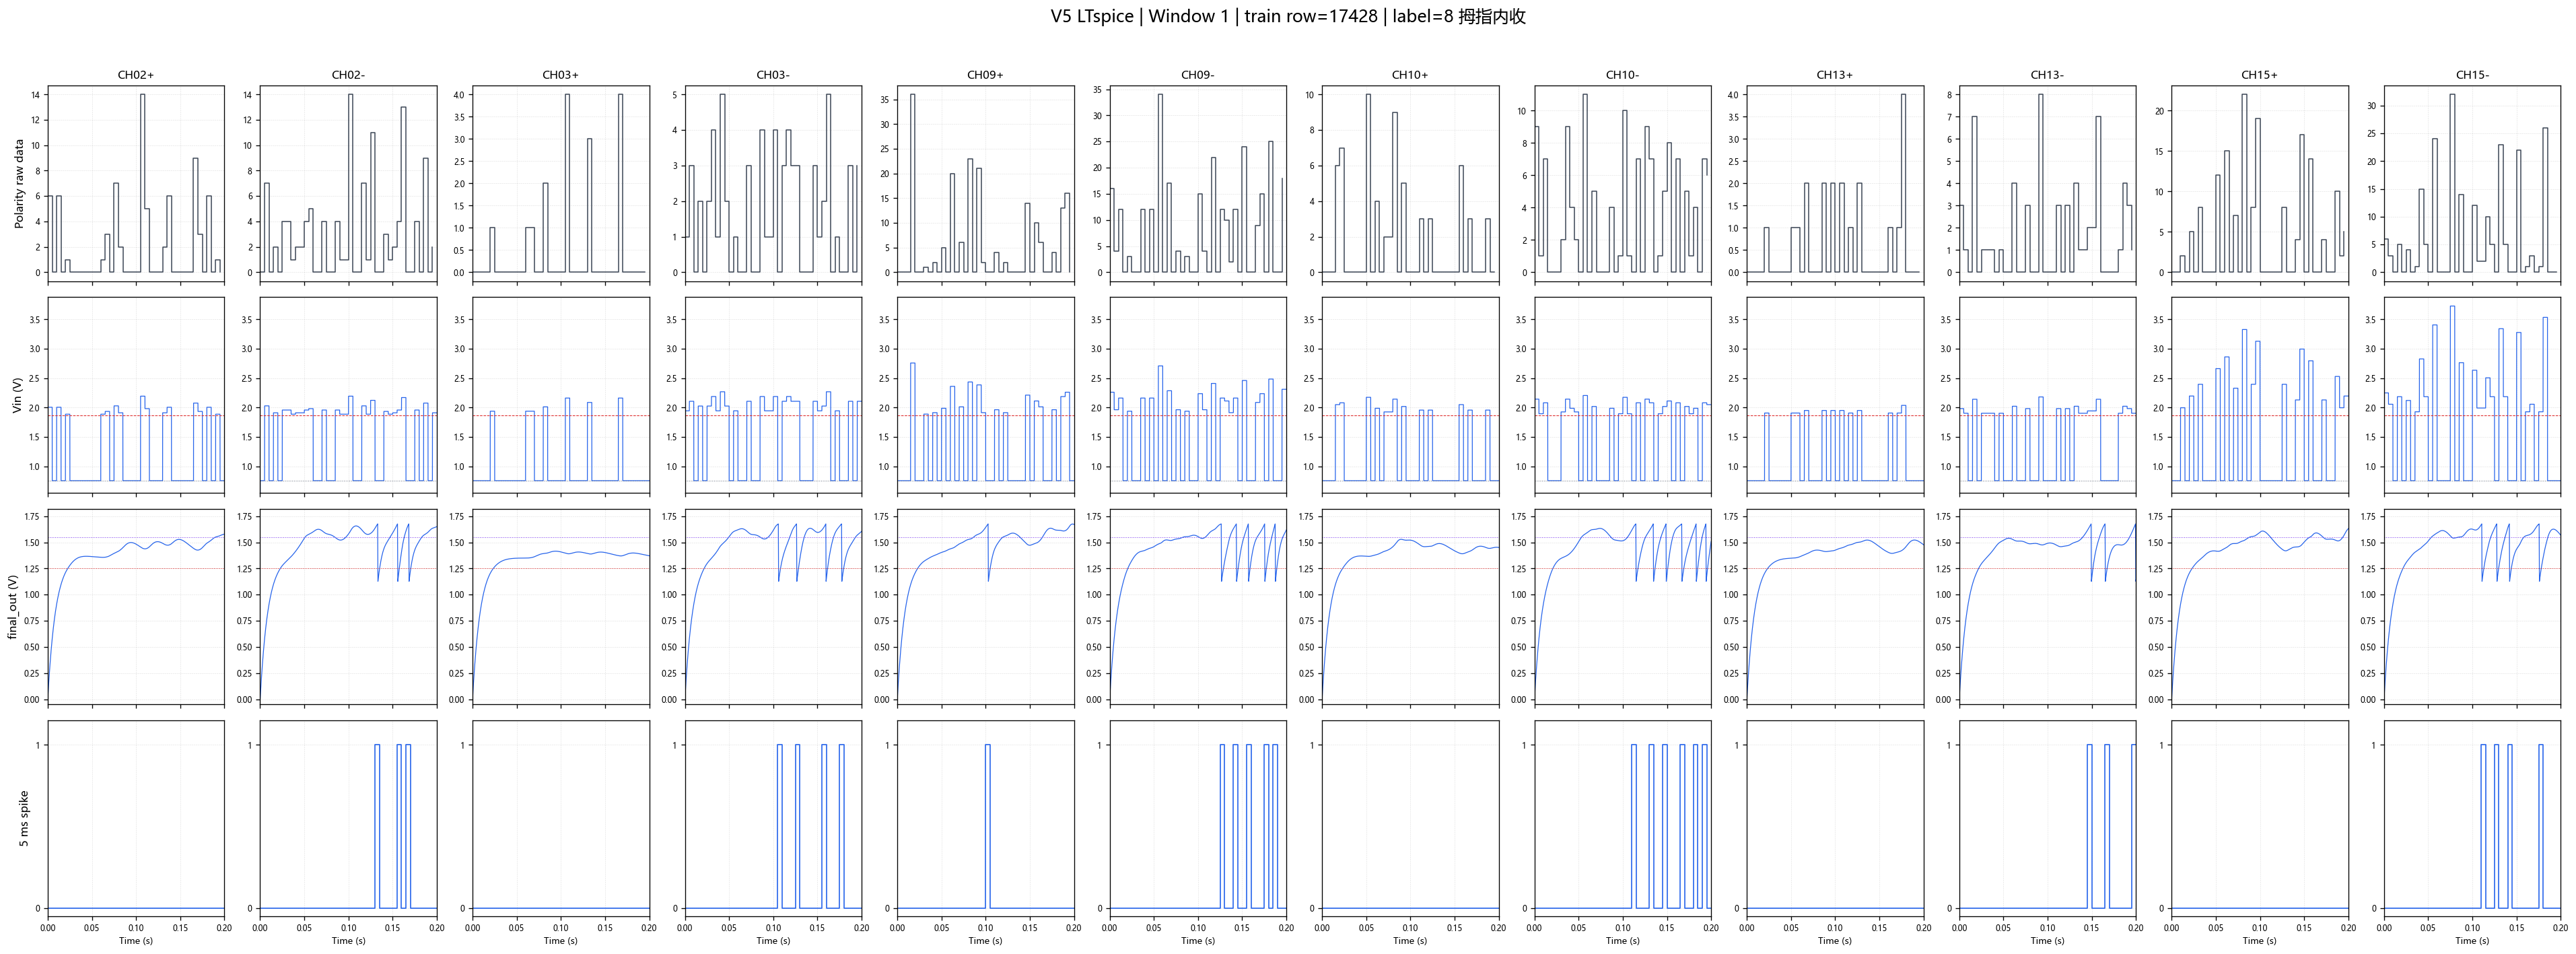

window_01_python.png


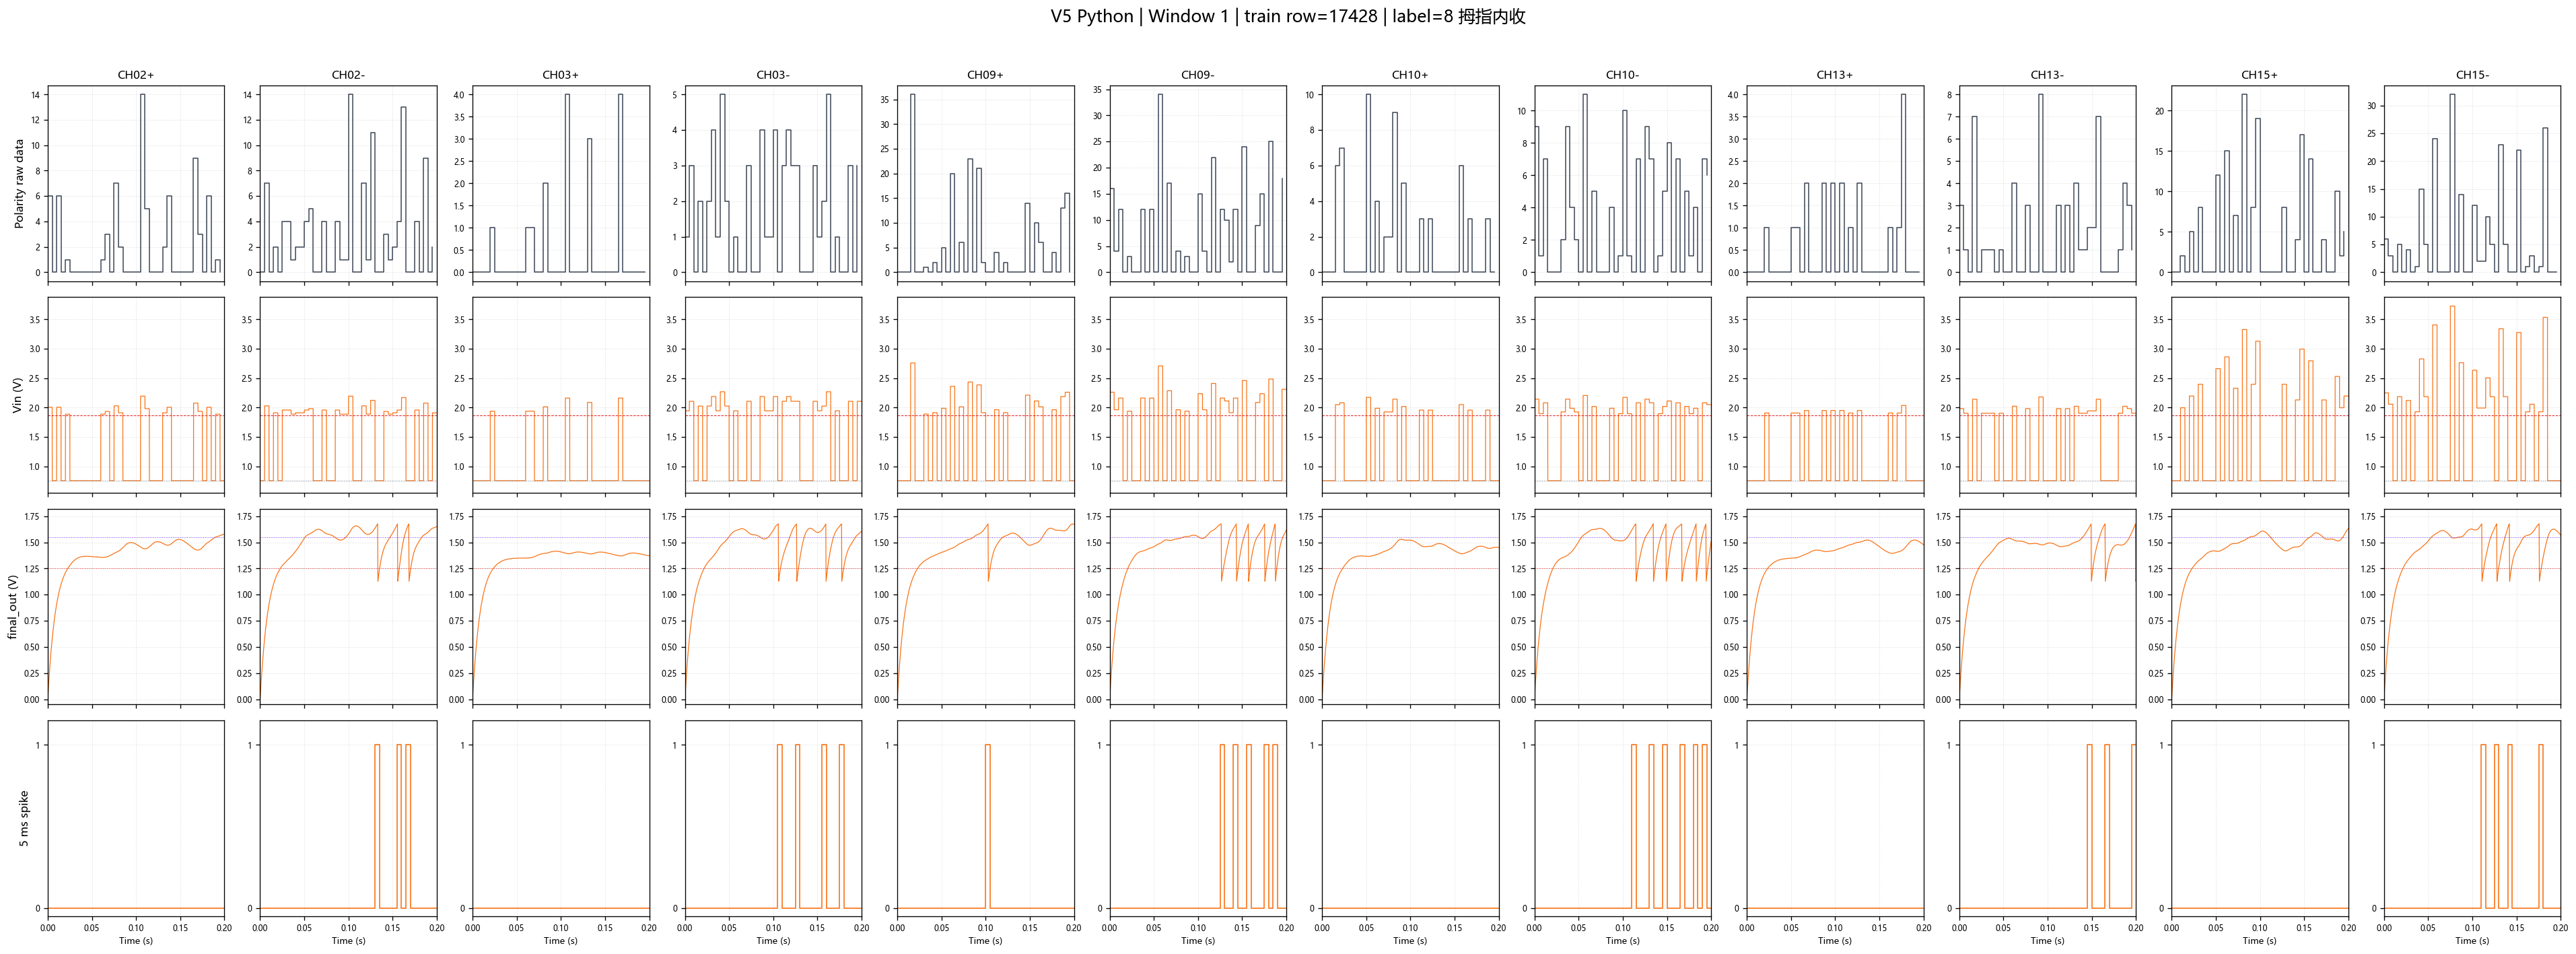

window_02_ltspice.png


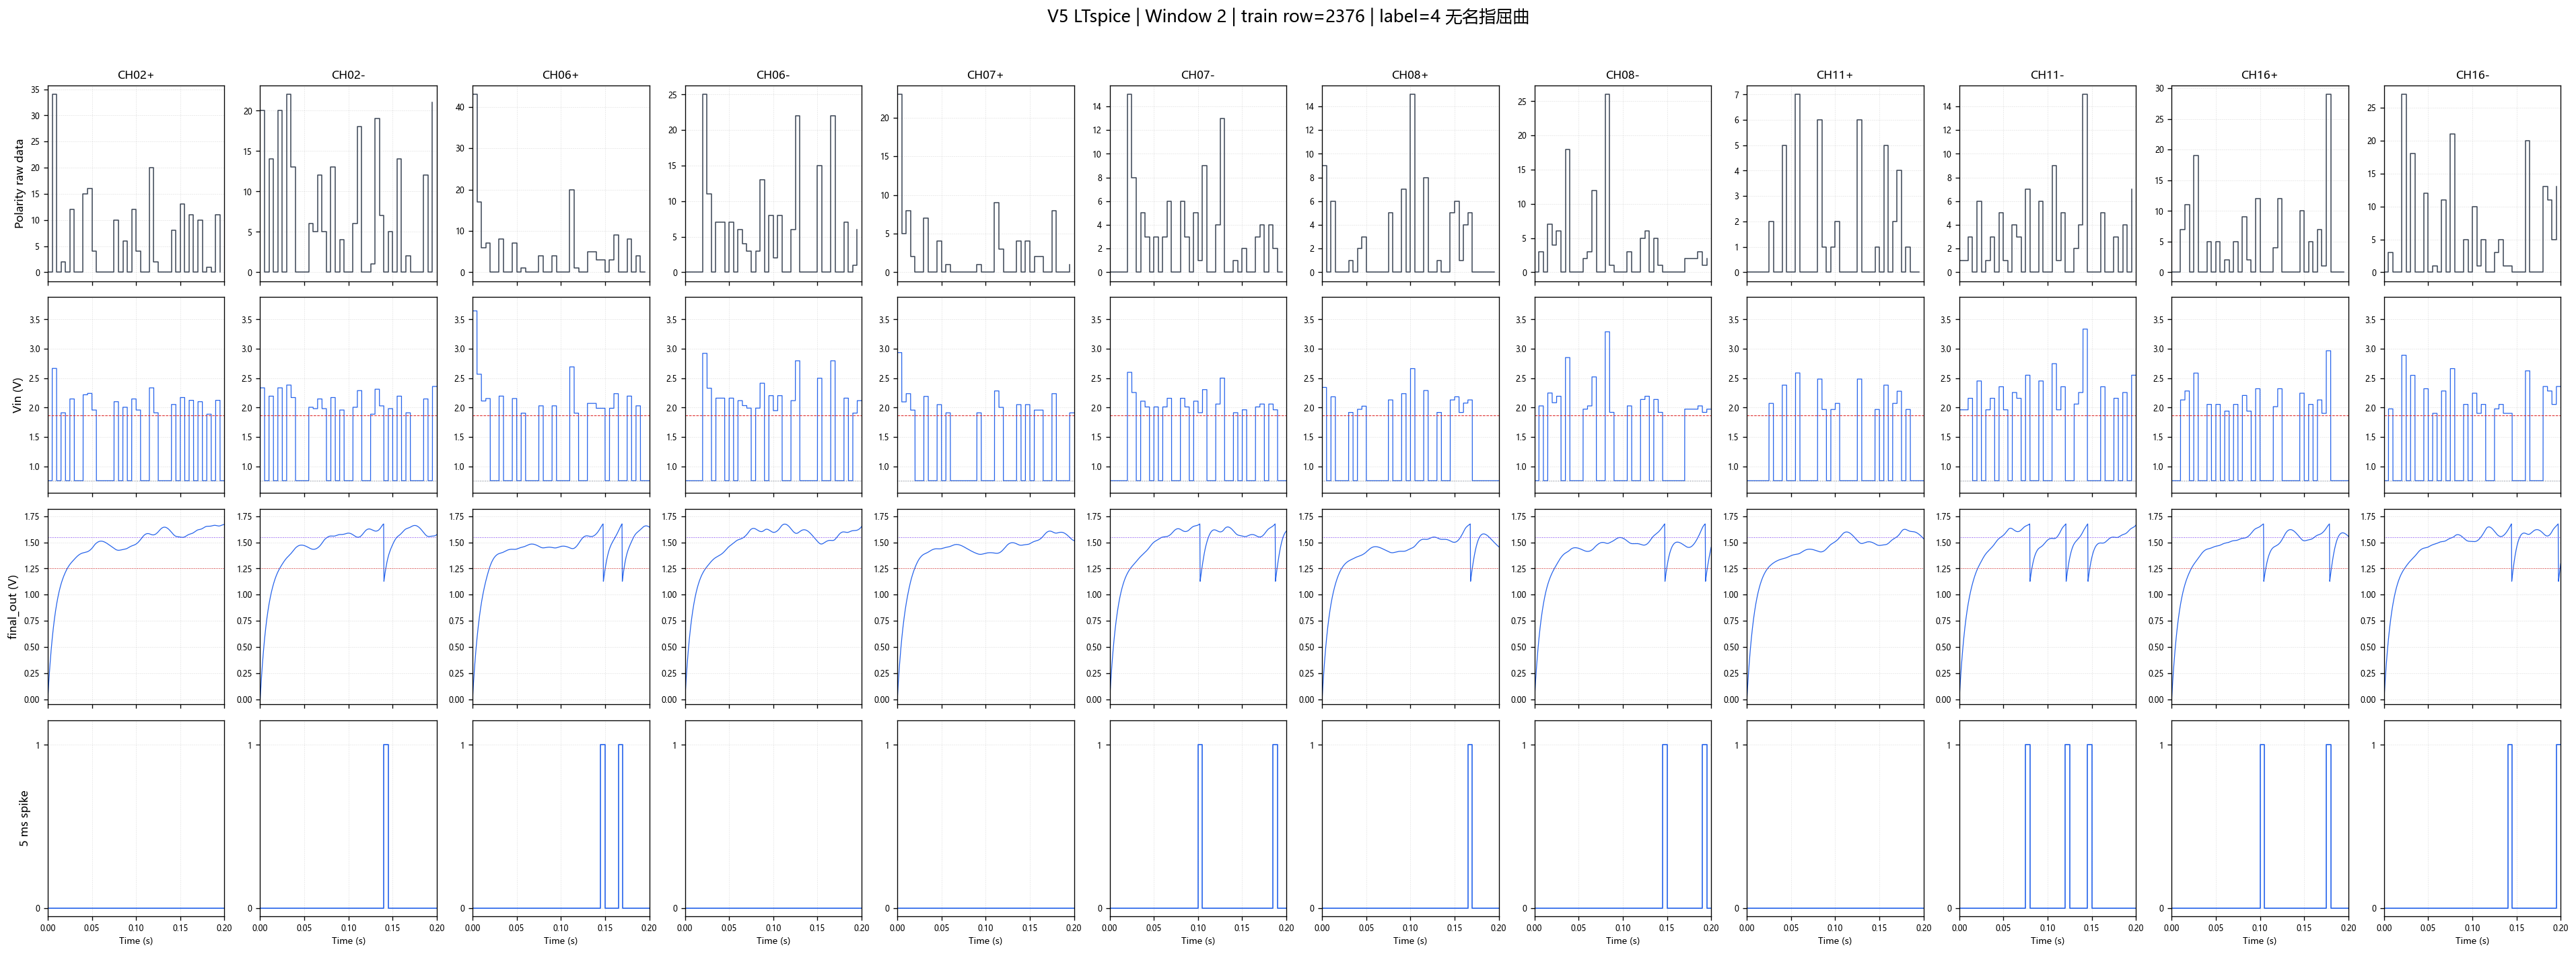

window_02_python.png


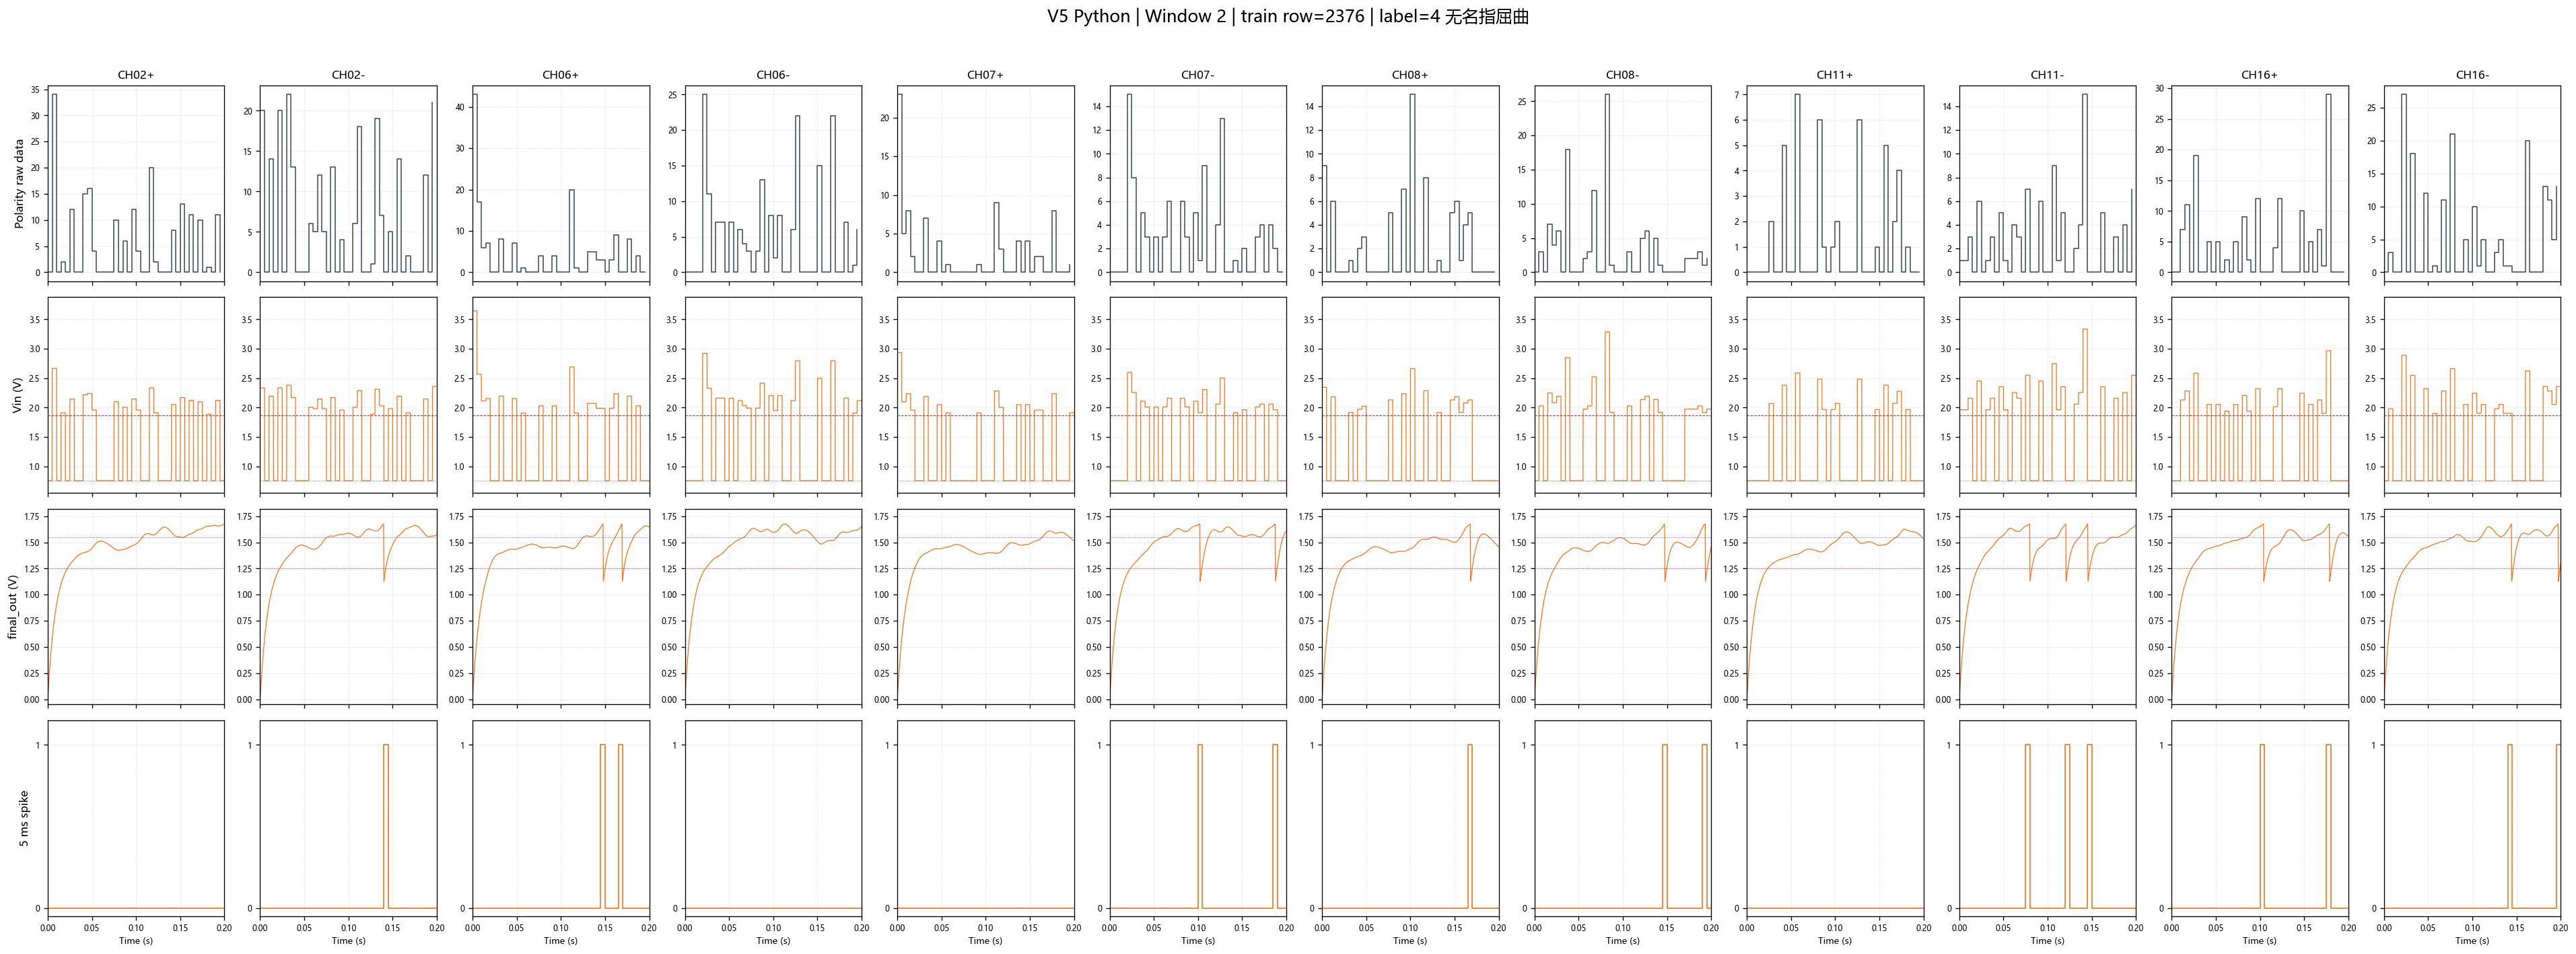

window_03_ltspice.png


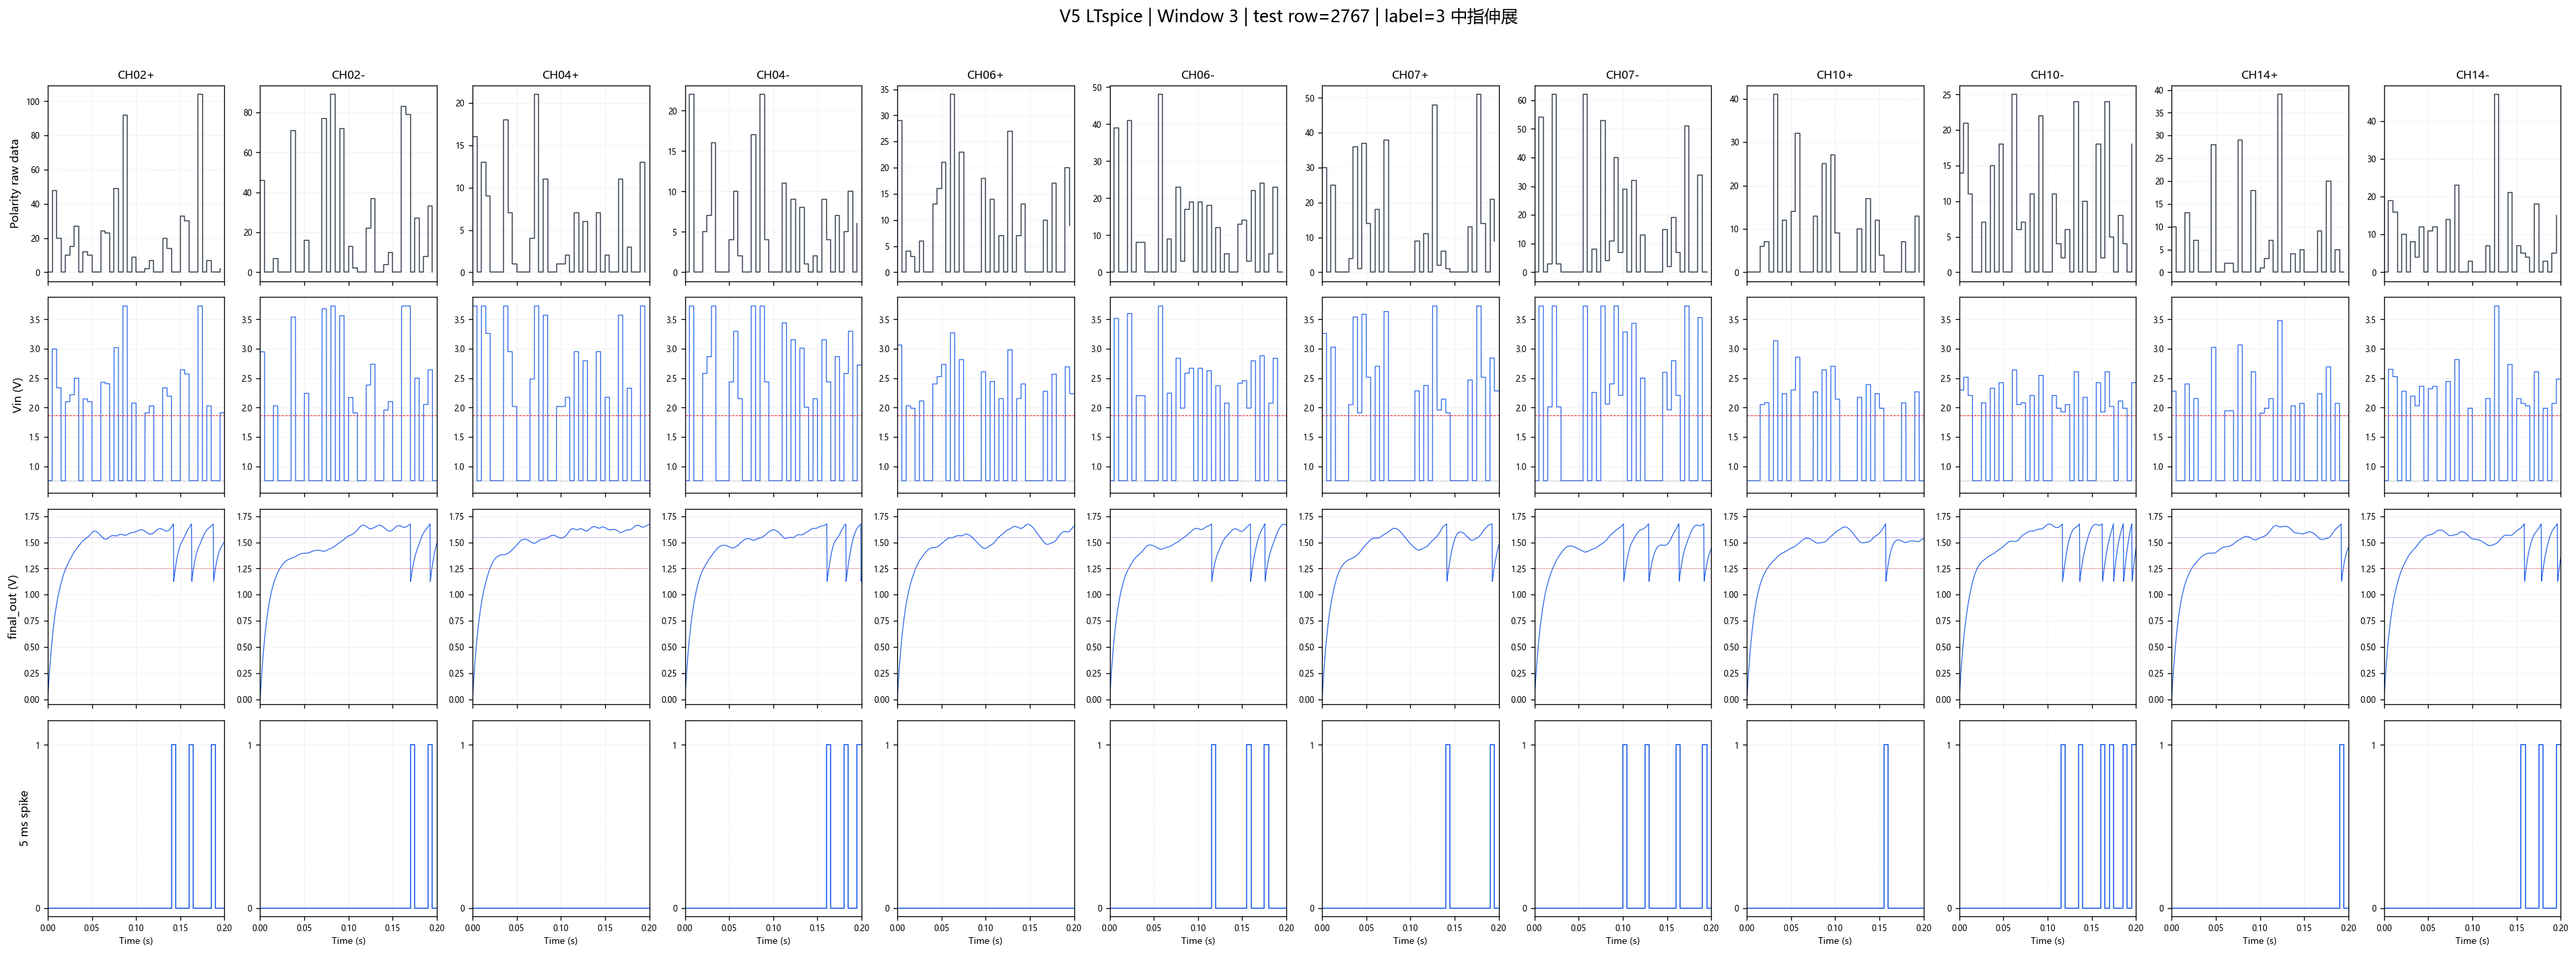

window_03_python.png


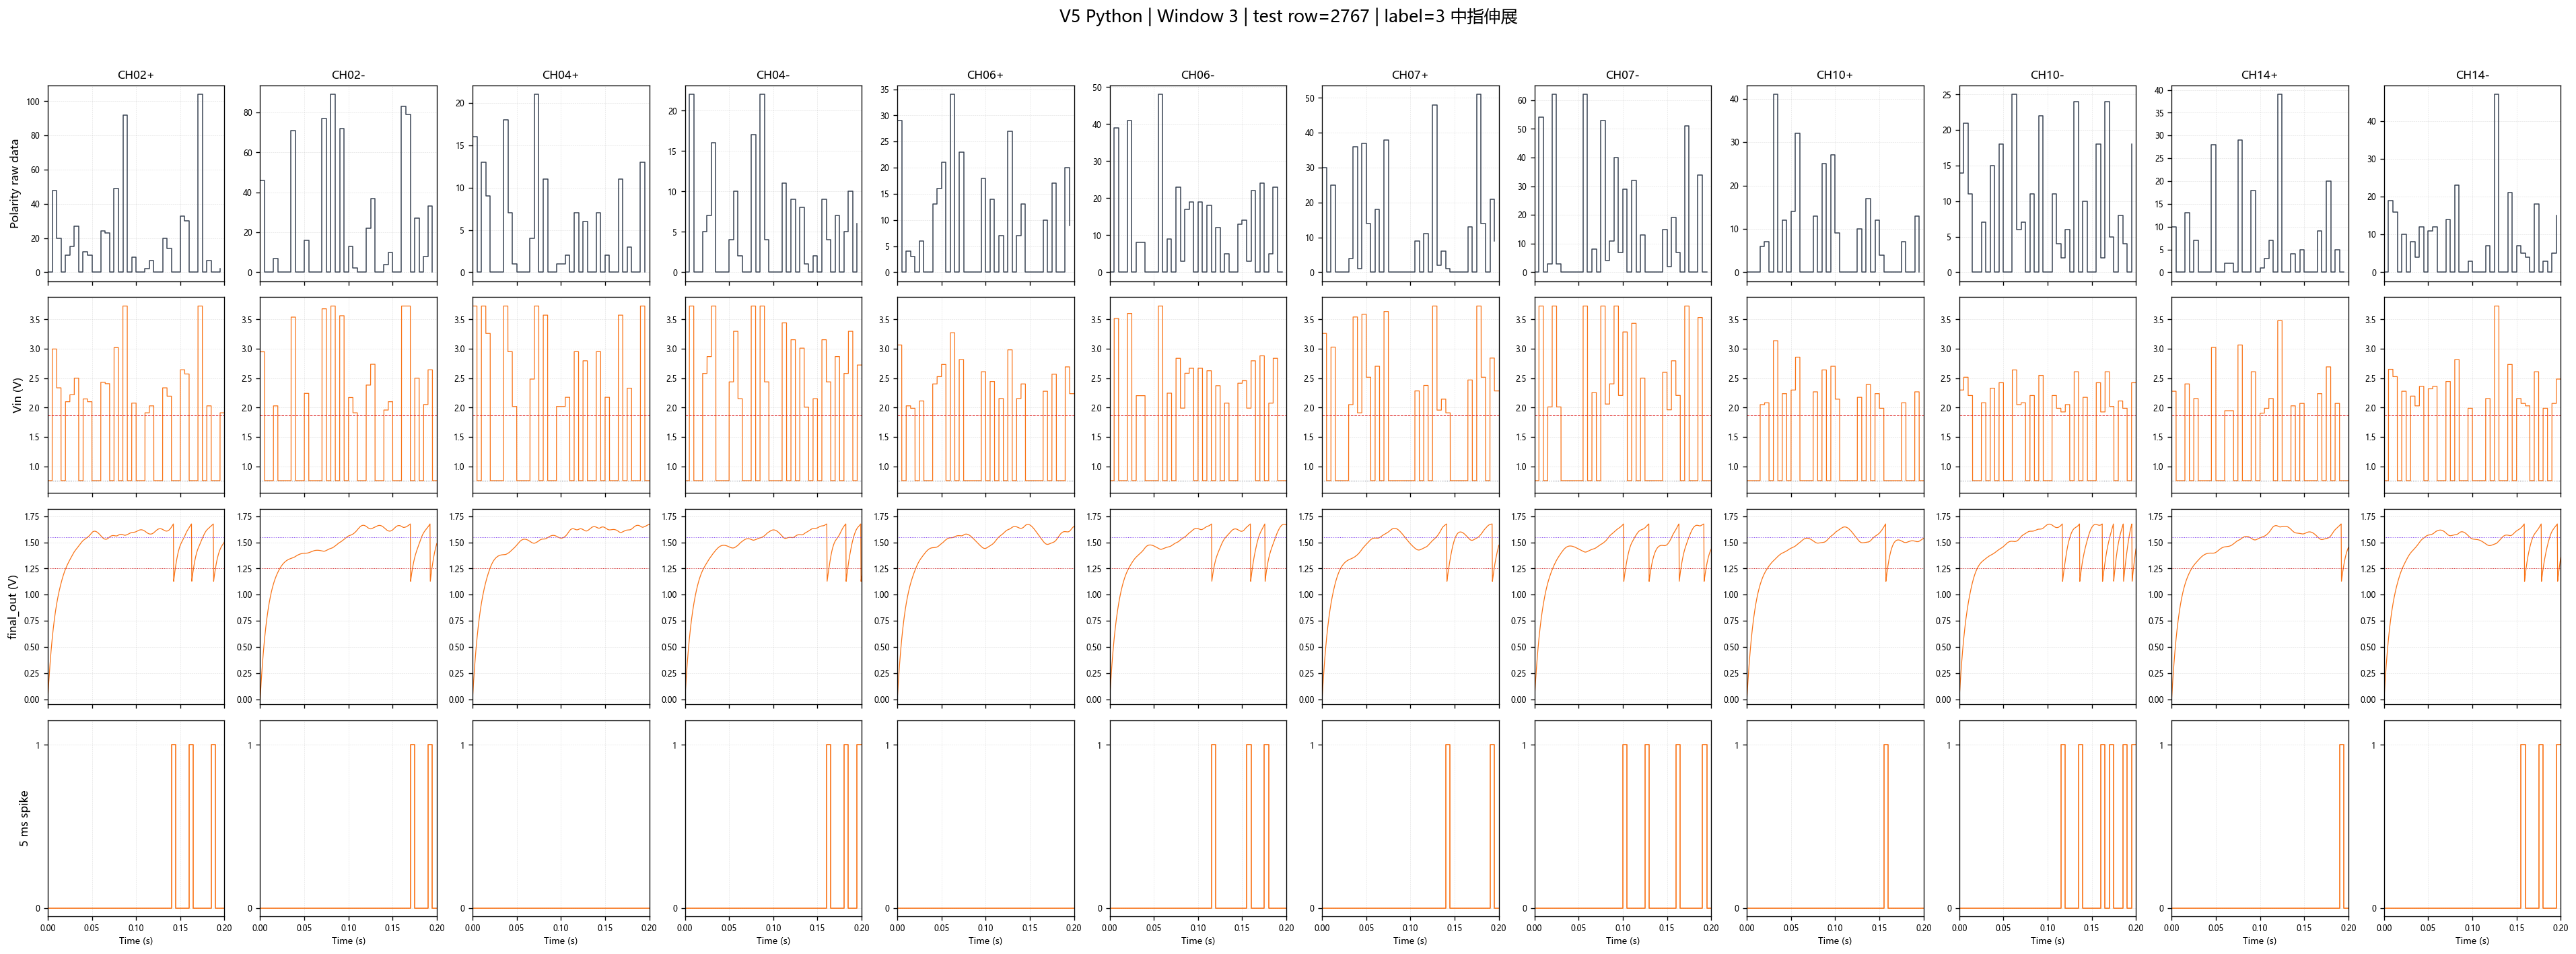

In [5]:
# 5. 为每个窗口分别绘制 LTspice 和 Python 的四类结果
plt.rcParams["font.sans-serif"] = [
    "Microsoft YaHei",
    "SimHei",
    "Noto Sans CJK SC",
    "DejaVu Sans",
]
plt.rcParams["axes.unicode_minus"] = False
sample_times = np.arange(WINDOW_SAMPLES, dtype=np.float64) / SAMPLE_RATE
bin_edges = np.linspace(0.0, WINDOW_DURATION, SPIKE_BINS + 1)


def plot_window_solver(selection, solver_name):
    """按相同布局绘制一个窗口的 12 条极性分支，便于跨求解器核对。"""
    window_results = [
        result
        for result in simulation_results
        if result["window_number"] == selection["window_number"]
    ]
    if len(window_results) != CHANNELS_PER_WINDOW * 2:
        raise AssertionError("单窗口极性分支数量异常")

    figure, axes = plt.subplots(
        4,
        len(window_results),
        figsize=(32, 12),
        dpi=120,
        sharex="col",
    )
    for column, result in enumerate(window_results):
        axes[0, column].step(
            sample_times,
            result["branch_raw"],
            where="post",
            color="#374151",
            linewidth=0.9,
        )
        axes[0, column].set_title(result["branch_name"], fontsize=10)

        if solver_name == "LTspice":
            time_values = result["lt_time"]
            vin_values = result["lt_vin"]
            final_out = result["lt_final_out"]
            spikes = result["lt_spikes"]
            color = "#2563eb"
        else:
            time_values = result["py_time"]
            vin_values = result["py_vin"]
            final_out = result["py_final_out"]
            spikes = result["py_spikes"]
            color = "#f97316"

        axes[1, column].plot(
            time_values,
            vin_values,
            color=color,
            linewidth=0.75,
        )
        axes[1, column].set_ylim(0.55, MAXIMUM_VOLTAGE + 0.15)
        axes[1, column].axhline(
            IDLE_VOLTAGE,
            color="#6b7280",
            linestyle=":",
            linewidth=0.6,
        )
        axes[1, column].axhline(
            ACTIVE_BASELINE_VOLTAGE,
            color="#dc2626",
            linestyle="--",
            linewidth=0.6,
        )

        axes[2, column].plot(
            time_values,
            final_out,
            color=color,
            linewidth=0.75,
        )
        axes[2, column].set_ylim(-0.05, 1.82)
        axes[2, column].axhline(
            PARAMETERS.spike_arm_voltage,
            color="#7c3aed",
            linestyle=":",
            linewidth=0.6,
        )
        axes[2, column].axhline(
            PARAMETERS.spike_fire_voltage,
            color="#dc2626",
            linestyle=":",
            linewidth=0.6,
        )

        spike_for_plot = np.r_[spikes, spikes[-1]]
        axes[3, column].step(
            bin_edges,
            spike_for_plot,
            where="post",
            color=color,
            linewidth=1.0,
        )
        axes[3, column].set_ylim(-0.05, 1.15)
        axes[3, column].set_yticks([0, 1])
        axes[3, column].set_xlabel("Time (s)", fontsize=8)

        for row in range(4):
            axes[row, column].set_xlim(0.0, WINDOW_DURATION)
            axes[row, column].grid(
                True,
                linestyle="--",
                linewidth=0.35,
                alpha=0.4,
            )
            axes[row, column].tick_params(labelsize=7)

    axes[0, 0].set_ylabel("Polarity raw data")
    axes[1, 0].set_ylabel("Vin (V)")
    axes[2, 0].set_ylabel("final_out (V)")
    axes[3, 0].set_ylabel("5 ms spike")
    figure.suptitle(
        f"V5 {solver_name} | Window {selection['window_number']} | "
        f"{selection['split']} row={selection['row_index']} | "
        f"label={selection['label']} {selection['action_name_zh']}",
        fontsize=15,
    )
    figure.tight_layout(rect=(0.0, 0.0, 1.0, 0.96))
    safe_solver = solver_name.lower()
    image_path = RESULT_ROOT / (
        f"window_{selection['window_number']:02d}_{safe_solver}.png"
    )
    figure.savefig(image_path, bbox_inches="tight")
    plt.close(figure)
    return image_path


figure_paths = []
for selection in selection_records:
    for solver_name in ("LTspice", "Python"):
        figure_path = plot_window_solver(selection, solver_name)
        figure_paths.append(figure_path)
        print(figure_path.name)
        display(Image(filename=str(figure_path)))

In [6]:
# 6. 汇总 LTspice 与 Python 的一致性
metrics = pd.DataFrame(metric_rows)
metrics.to_csv(
    RESULT_ROOT / "ltspice_python_metrics.csv",
    index=False,
    encoding="utf-8-sig",
)

window_comparison = (
    metrics.groupby(
        ["window_number", "split", "row_index", "label", "action_name_zh"],
        as_index=False,
    )
    .agg(
        lt_total_spikes=("lt_spike_count", "sum"),
        py_total_spikes=("py_spike_count", "sum"),
        exact_spike_count_branches=("spike_count_exact", "sum"),
        exact_binary_branches=("spike_binary_exact", "sum"),
        mean_binary_agreement=("spike_binary_agreement", "mean"),
        mean_final_out_rmse=("final_out_rmse", "mean"),
        mean_final_out_correlation=("final_out_correlation", "mean"),
    )
)

total_lt_spikes = int(metrics["lt_spike_count"].sum())
total_py_spikes = int(metrics["py_spike_count"].sum())
active_lt_branches = int((metrics["lt_spike_count"] > 0).sum())
active_py_branches = int((metrics["py_spike_count"] > 0).sum())
silent_lt_branches = int(metrics.shape[0] - active_lt_branches)
silent_py_branches = int(metrics.shape[0] - active_py_branches)
mean_lt_frequency_hz = float(
    total_lt_spikes / (metrics.shape[0] * WINDOW_DURATION)
)
mean_py_frequency_hz = float(
    total_py_spikes / (metrics.shape[0] * WINDOW_DURATION)
)
exact_count_branches = int(metrics["spike_count_exact"].sum())
exact_binary_branches = int(metrics["spike_binary_exact"].sum())
mean_binary_agreement = float(metrics["spike_binary_agreement"].mean())
all_binary_exact = bool(metrics["spike_binary_exact"].all())

summary = {
    "random_seed": RANDOM_SEED,
    "window_count": WINDOW_COUNT,
    "channels_per_window": CHANNELS_PER_WINDOW,
    "polarity_branch_count": int(metrics.shape[0]),
    "mapping": {
        "idle_voltage": IDLE_VOLTAGE,
        "active_baseline_voltage": ACTIVE_BASELINE_VOLTAGE,
        "maximum_voltage": MAXIMUM_VOLTAGE,
        "positive_endpoint": "per-channel p99",
        "negative_endpoint": "absolute per-channel p1",
    },
    "ltspice_total_spikes": total_lt_spikes,
    "python_total_spikes": total_py_spikes,
    "ltspice_active_branches": active_lt_branches,
    "python_active_branches": active_py_branches,
    "ltspice_silent_branches": silent_lt_branches,
    "python_silent_branches": silent_py_branches,
    "ltspice_mean_frequency_hz": mean_lt_frequency_hz,
    "python_mean_frequency_hz": mean_py_frequency_hz,
    "exact_spike_count_branches": exact_count_branches,
    "exact_binary_branches": exact_binary_branches,
    "mean_binary_agreement": mean_binary_agreement,
    "all_5ms_binary_spikes_exact": all_binary_exact,
    "mean_final_out_rmse": float(metrics["final_out_rmse"].mean()),
    "mean_final_out_correlation": float(
        metrics["final_out_correlation"].mean()
    ),
    "figure_files": [path.name for path in figure_paths],
}
(RESULT_ROOT / "summary.json").write_text(
    json.dumps(summary, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

display(window_comparison)
display(
    metrics[
        [
            "window_number",
            "branch_name",
            "lt_spike_count",
            "py_spike_count",
            "spike_count_exact",
            "spike_binary_exact",
            "spike_binary_agreement",
            "final_out_rmse",
            "final_out_correlation",
        ]
    ]
)

print(f"LTspice 总脉冲数：{total_lt_spikes}")
print(f"Python 总脉冲数：{total_py_spikes}")
print(
    f"LTspice 活跃/静默分支："
    f"{active_lt_branches}/{silent_lt_branches}，"
    f"平均频率 {mean_lt_frequency_hz:.4f} Hz"
)
print(
    f"Python 活跃/静默分支："
    f"{active_py_branches}/{silent_py_branches}，"
    f"平均频率 {mean_py_frequency_hz:.4f} Hz"
)
print(
    f"脉冲数量完全一致的分支：{exact_count_branches}/{metrics.shape[0]}"
)
print(
    f"5 ms 二值脉冲完全一致的分支："
    f"{exact_binary_branches}/{metrics.shape[0]}"
)
print(f"平均时间箱一致率：{mean_binary_agreement:.4%}")
if all_binary_exact:
    print("结论：本次抽样中 LTspice 与 Python 的 5 ms 脉冲编码完全一致。")
else:
    print("结论：本次抽样中 LTspice 与 Python 的脉冲编码不完全一致，详见逐分支指标。")

,window_number,split,row_index,label,action_name_zh,lt_total_spikes,py_total_spikes,exact_spike_count_branches,exact_binary_branches,mean_binary_agreement,mean_final_out_rmse,mean_final_out_correlation
0,1,train,17428,8,拇指内收,26,26,12,12,1.0,0.001776,0.999960
1,2,train,2376,4,无名指屈曲,15,15,12,12,1.0,0.001522,0.999974
2,3,test,2767,3,中指伸展,28,28,12,12,1.0,0.002713,0.999866


,window_number,branch_name,lt_spike_count,py_spike_count,spike_count_exact,spike_binary_exact,spike_binary_agreement,final_out_rmse,final_out_correlation
0,1,CH02+,0,0,True,True,1.0,0.000117,1.000000
1,1,CH02-,3,3,True,True,1.0,0.003718,0.999902
2,1,CH03+,0,0,True,True,1.0,0.000045,1.000000
3,1,CH03-,4,4,True,True,1.0,0.003636,0.999906
4,1,CH09+,1,1,True,True,1.0,0.001886,0.999973
5,1,CH09-,5,5,True,True,1.0,0.002931,0.999934
6,1,CH10+,0,0,True,True,1.0,0.000096,1.000000
7,1,CH10-,6,6,True,True,1.0,0.003604,0.999907
8,1,CH13+,0,0,True,True,1.0,0.000097,1.000000
9,1,CH13-,3,3,True,True,1.0,0.002729,0.999937


LTspice 总脉冲数：69
Python 总脉冲数：69
LTspice 活跃/静默分支：25/11，平均频率 9.5833 Hz
Python 活跃/静默分支：25/11，平均频率 9.5833 Hz
脉冲数量完全一致的分支：36/36
5 ms 二值脉冲完全一致的分支：36/36
平均时间箱一致率：100.0000%
结论：本次抽样中 LTspice 与 Python 的 5 ms 脉冲编码完全一致。
